# 使用两层 ReLU 神经网络拟合任意函数

理论和实验证明，一个两层的 ReLU 网络可以模拟任何函数（万能近似定理）。本实验中，我们将自行定义一个非线性函数，并纯手工使用 NumPy 实现一个两层的神经网络（一个隐藏层，使用 ReLU 激活）来拟合该函数。

## 1. 准备工作：定义函数与生成数据
我们将使用一个包含正弦和线性分量的函数：$f(x) = \sin(x) + 0.5x$

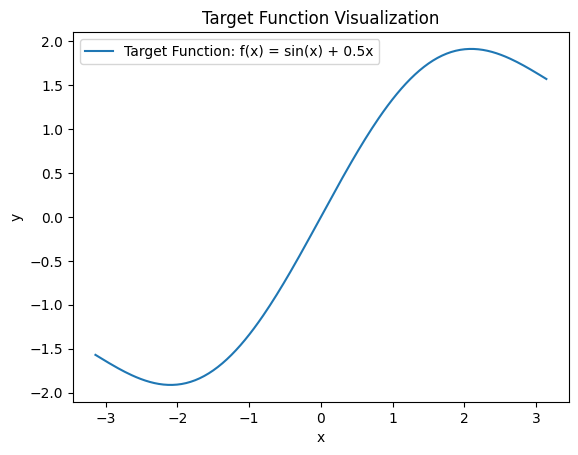

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 定义目标函数
def target_function(x):
    return np.sin(x) + 0.5 * x

# 生成训练数据 (在 -pi 到 pi 之间均匀采样)
np.random.seed(42)
X = np.linspace(-np.pi, np.pi, 200).reshape(-1, 1)
y = target_function(X)

# 可视化目标形状
plt.plot(X, y, label='Target Function: f(x) = sin(x) + 0.5x')
plt.title('Target Function Visualization')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 2. 定义 ReLU 激活函数及其导数

前向传播使用 ReLU，反向传播时需要计算其导数（大于 0 时导数为 1，否则为 0）。

In [5]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

## 3. 构建与训练两层神经网络

网络结构设计如下：
- **输入层**: 1 个特征 ($x$)
- **隐藏层**: 包含 128 个神经元，使用 ReLU 激活
- **输出层**: 1 个特征 ($y$)，无激活（即线性输出层）

我们将使用均方误差（MSE）作为损失函数，使用经典的梯度下降（Gradient Descent）来更新网络权重。

In [6]:
# 网络架构参数
input_size = 1
hidden_size = 128  # 足够多的神经元可以增强网络的函数逼近能力
output_size = 1

# 训练参数
learning_rate = 0.005
epochs = 8000

# 初始化权重和偏置
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

losses = []

# 训练循环
for epoch in range(epochs):
    # --- 前向传播 (Forward Pass) ---
    Z1 = np.dot(X, W1) + b1       # 隐藏层线性组合
    A1 = relu(Z1)                 # 隐藏层激活
    Z2 = np.dot(A1, W2) + b2      # 输出层
    y_pred = Z2
    
    # 计算损失 (MSE Loss)
    loss = np.mean((y_pred - y) ** 2)
    losses.append(loss)
    
    # --- 反向传播 (Backward Pass) ---
    # 计算输出误差导数: dL/dy_pred
    d_y_pred = 2.0 * (y_pred - y) / y.shape[0]
    
    # 输出层梯度
    d_W2 = np.dot(A1.T, d_y_pred)
    d_b2 = np.sum(d_y_pred, axis=0, keepdims=True)
    
    # 隐藏层梯度
    d_A1 = np.dot(d_y_pred, W2.T)
    d_Z1 = d_A1 * relu_derivative(Z1)
    
    d_W1 = np.dot(X.T, d_Z1)
    d_b1 = np.sum(d_Z1, axis=0, keepdims=True)
    
    # --- 参数更新 ---
    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1
    W2 -= learning_rate * d_W2
    b2 -= learning_rate * d_b2
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss:.6f}")

Epoch [1000/8000], Loss: 0.084539
Epoch [2000/8000], Loss: 0.058563
Epoch [3000/8000], Loss: 0.039876
Epoch [4000/8000], Loss: 0.025549
Epoch [5000/8000], Loss: 0.016201
Epoch [6000/8000], Loss: 0.010650
Epoch [7000/8000], Loss: 0.007351
Epoch [8000/8000], Loss: 0.005315


## 4. 结果可视化
将神经网络输出的预测值与真实的函数曲线进行对比，以验证基于 ReLU 的两层网络确实例模拟到了非线性函数。

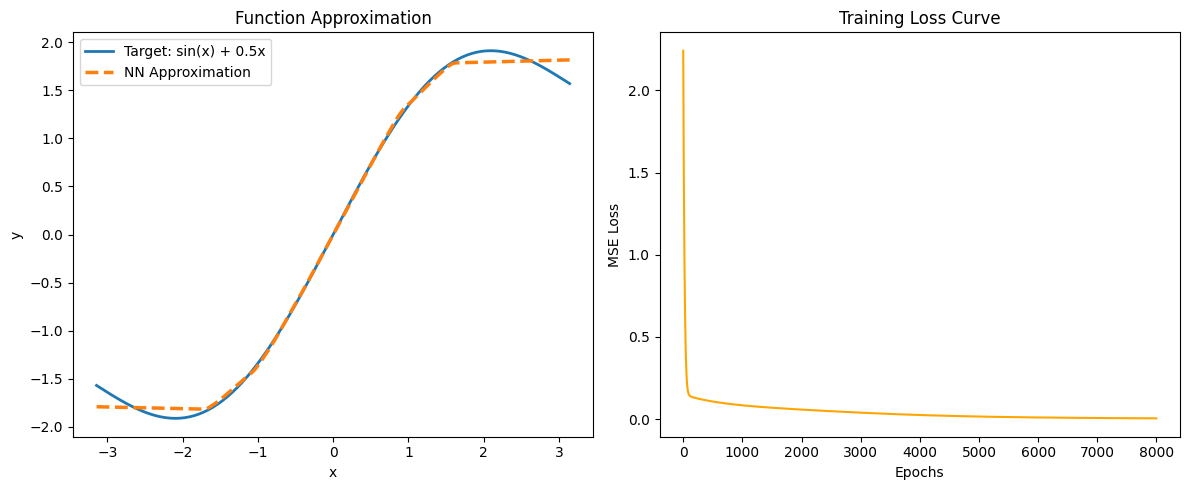

In [7]:
plt.figure(figsize=(12, 5))

# 绘制拟合对比图
plt.subplot(1, 2, 1)
plt.plot(X, y, label='Target: sin(x) + 0.5x', linewidth=2)
plt.plot(X, y_pred, label='NN Approximation', linestyle='--', linewidth=2.5)
plt.title('Function Approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# 绘制 Loss 曲线图
plt.subplot(1, 2, 2)
plt.plot(losses, color='orange')
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')

plt.tight_layout()
plt.show()